# Projet de Physique Numérique: retrouver les niveaux d'énergie d'un atome alkalin

## Première partie: l'atome d'hydrogène

## 1

In [508]:
"""Importation des modules"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import *
from scipy.special import sph_harm
from scipy.integrate import *
from mpl_toolkits import mplot3d

In [509]:
n=10001
L=100
R=np.linspace(0,L,n) #vecteur des coordonnées r
R+=L/(n-1)

## 1

In [510]:
#Quand l=0, les niveaux d'énergie sont les valeurs propres de l'hamiltonien, rangées dans l'ordre croissant
#Si on prend l>0, les premières énergies propres ne sont pas présentes

def Potentielhydrogène(r): #l=0
    l=0
    return (-1)/r + l*(l+1)/(2*r**2)
Potentielhydrogène=np.vectorize(Potentielhydrogène)

def Schrodinger(U): 
    d=R[1]-R[0]  #pas d'échantillonnage
    Hd=np.zeros(n) #diagonale de la matrice H
    for k in range(n):
        Hd[k]=1/(d**2) + U[k]
    Hsousd=np.zeros(n-1) #sous-diagonale de la matrice H
    for k in range(n-1):
        Hsousd[k]=-1/(2*(d**2))
    valeurs_propres, vecteurs_propres = eigh_tridiagonal(Hd,Hsousd, select='v', select_range=(-np.inf,0))
    return valeurs_propres, vecteurs_propres

In [511]:
print("Configuration 1s, énergie E1=", Schrodinger(Potentielhydrogène(R))[0][0]*27.2) #l'échelle est en Hartree 
print ("Valeur théorique attendue: -13.6")
print("Configuration 2s, énergie E2=", Schrodinger(Potentielhydrogène(R))[0][1]*27.2)
print ("Valeur théorique attendue: -3.4")
print("Configuration 3s, énergie E3=", Schrodinger(Potentielhydrogène(R))[0][2]*27.2)
print ("Valeur théorique attendue: -1.51")
print("Configuration 4s, énergie E4=", Schrodinger(Potentielhydrogène(R))[0][3]*27.2)
print ("Valeur théorique attendue: -0.85")
print("Configuration 5s, énergie E5=", Schrodinger(Potentielhydrogène(R))[0][4]*27.2)
print ("Valeur théorique attendue: -0.54")

Configuration 1s, énergie E1= -13.599660017007594
Valeur théorique attendue: -13.6
Configuration 2s, énergie E2= -3.3999787502632954
Valeur théorique attendue: -3.4
Configuration 3s, énergie E3= -1.5111069135916824
Valeur théorique attendue: -1.51
Configuration 4s, énergie E4= -0.8499986718842
Valeur théorique attendue: -0.85
Configuration 5s, énergie E5= -0.5439986852281739
Valeur théorique attendue: -0.54


On retrouve les niveaux d'énergie de l'atome d'hydrogène. Il faudra dans la suite faire attention à la façon de choisir le rayon R sur lequel on résout l'équation de Schrödinger disctrétisée ainsi que le pas de discrétisation.

Il faut que le pas $\delta$ << longueurs typiques de variation de $u_{n,l}(r)$, et que R>> taille typique du domaine de présence de l'électron.

## 2

In [512]:
def Potentielhydrogène1(r): #l=1
    l=1
    return (-1)/r + l*(l+1)/(2*r**2)
Potentielhydrogène1=np.vectorize(Potentielhydrogène1)

def Potentielhydrogène2(r): #l=2
    l=2
    return (-1)/r + l*(l+1)/(2*r**2)
Potentielhydrogène2=np.vectorize(Potentielhydrogène2)


In [513]:
print("Configuration 2s, énergie=", Schrodinger(Potentielhydrogène(R))[0][1]*27.2)
print("Configuration 2p, énergie=", Schrodinger(Potentielhydrogène1(R))[0][0]*27.2)

print("Configuration 3s, énergie=", Schrodinger(Potentielhydrogène(R))[0][2]*27.2)
print("Configuration 3p, énergie=", Schrodinger(Potentielhydrogène1(R))[0][1]*27.2)
print("Configuration 3d, énergie=", Schrodinger(Potentielhydrogène2(R))[0][0]*27.2)

# Attention n>l donc a l fixée, la première énergie propre trouvée par eigtridiagonale est l'énergie numéro E_{l+1}

Configuration 2s, énergie= -3.3999787502632954
Configuration 2p, énergie= -3.4000070834298057
Configuration 3s, énergie= -1.5111069135916824
Configuration 3p, énergie= -1.5111143758963386
Configuration 3d, énergie= -1.51111139085152


On retrouve que les niveaux d'énergie 2s et 2p sont dégénérés, ainsi que les niveaux des orbites 3s, 3p, et 3d.

## 3

Niveaux d'énergies en eV: [-13.599660017007594, -3.3999787502632954, -3.4000070834298057, -1.5111069135916824, -1.5111143758963386, -0.8499986718842, -1.51111139085152, -0.8500016823315616]


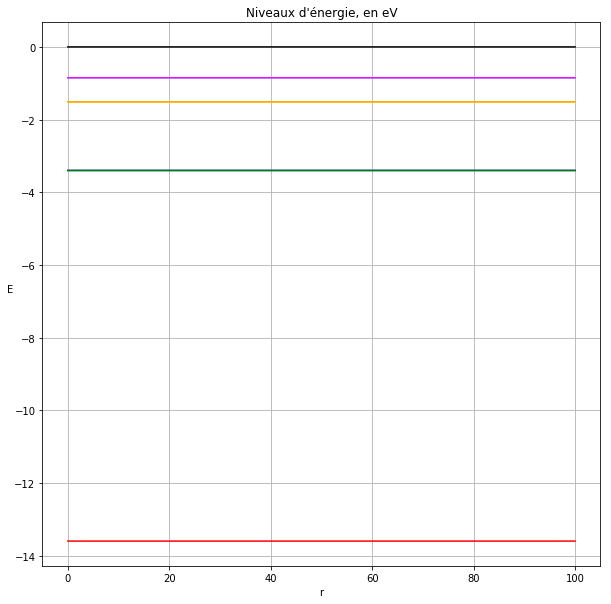

In [581]:
def diagr_En(En):
    Liste=[]
    for i in range(len(En)):
        Liste.append(En[i]*27.2)
    print("Niveaux d'énergies en eV:", Liste)
    plt.figure(figsize=(10,10))
    plt.plot(R,np.zeros(n), color='k')
    colors = ('red', 'blue', 'green', 'violet', 'yellow', 'cyan', 
    'orange', 'magenta')
    
    for k in range(len(En)):
        plt.plot(R, En[k]*np.ones(n)*27.2, color=colors[k%8])

    plt.title("Niveaux d'énergie, en eV")
    plt.xlabel('r')
    plt.ylabel('E', rotation=360)
    plt.grid()
    plt.show()

''''Application à l'atome d'hydrogène'''
Sch0H=Schrodinger(Potentielhydrogène(R))[0]
Sch1H=Schrodinger(Potentielhydrogène1(R))[0]
Sch2H=Schrodinger(Potentielhydrogène2(R))[0]
En_Hydro=[Sch0H[0],Sch0H[1],Sch1H[0],Sch0H[2],Sch1H[1],Sch0H[3],Sch2H[0],Sch1H[2]] # =[1s,2s,2p,3s,3p,4s,3d,4p]

diagr_En(En_Hydro)

On observe que 4 traits. On retrouve ici la dégénerescence des niveaux d'énergies des orbitales de l'atome d'hydrogène.

## 4

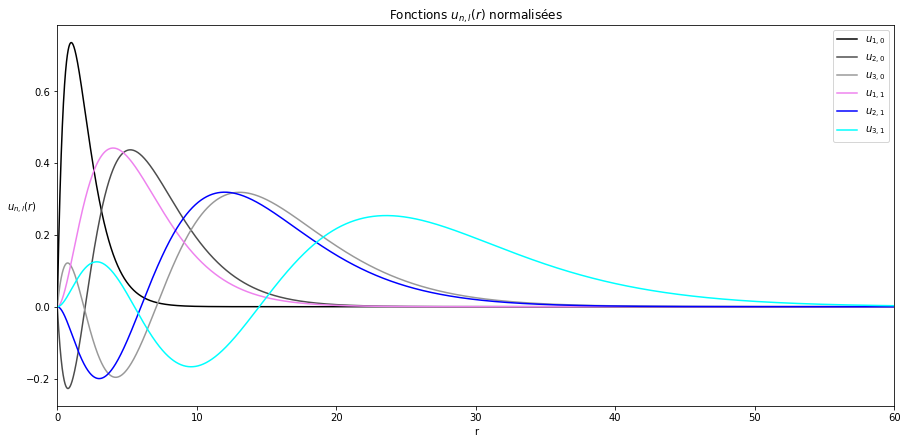

In [515]:
plt.figure(figsize=(15,7))
d=R[1]-R[0]

plt.plot(R,Schrodinger(Potentielhydrogène(R))[1][:,0]/(d**0.5), label="$u_{1,0}$", color='0')
plt.plot(R,Schrodinger(Potentielhydrogène(R))[1][:,1]/(d**0.5), label="$u_{2,0}$", color='0.3')
plt.plot(R,Schrodinger(Potentielhydrogène(R))[1][:,2]/(d**0.5), label="$u_{3,0}$", color='0.6')

plt.plot(R,Schrodinger(Potentielhydrogène1(R))[1][:,0]/(d**0.5), label="$u_{1,1}$", color='violet')
plt.plot(R,Schrodinger(Potentielhydrogène1(R))[1][:,1]/(d**0.5), label="$u_{2,1}$", color='blue')
plt.plot(R,Schrodinger(Potentielhydrogène1(R))[1][:,2]/(d**0.5), label="$u_{3,1}$", color='cyan')

plt.title("Fonctions $u_{n,l}(r)$ normalisées")
plt.xlabel('r')
plt.ylabel('$u_{n,l}(r)$', rotation=360)
plt.legend()
plt.xlim(0,60)

plt.show()

Les fonctions $u_{n,l}(r)$, c'est-à-dire les vecteurs propres renvoyés par eightridiagonal dans la fonction Schrodinger, sont déjà normalisés selon la régle: $$\sum  \left|u_{n,l}\right|^{2} = 1$$
On souhaite que $A u_{n,l}(r)$ soit normalisée telle que: $$\int \left|A u_{n,l}(r)\right|^{2} dr = 1$$ c'est-à-dire que: 
$$\sum  \left|A u_{n,l}\right|^{2} \delta  = 1$$ Il faut donc que la constante de normalisation A vérifie: 
$$\left|A\right|^{2}\times \delta =1$$ soit: $$A=\frac{1}{\sqrt\delta}$$
C'est ce qui a été fait pour tracer les fonctions $u_{n,l}(r)$ au-dessus.

## 5

In [516]:
def orb(n,l,m):
    L=['s','p','d','f']
    theta=np.linspace(0,np.pi,101)
    phi=np.linspace(0,2*np.pi,101)
    
    phph,thth=np.meshgrid(phi,theta)
    
    Ylm=sph_harm(m,l,phph,thth)
    ray=Ylm.real**2 + Ylm.imag**2
    
    X=ray*np.sin(thth)*np.cos(phph)
    Y=ray*np.sin(thth)*np.sin(phph)
    Z=ray*np.cos(thth)
    
    plt.figure(figsize=(10,8))
    
    ax=plt.axes(projection='3d')
    ax.set_xlim(-0.3,0.3)
    ax.set_ylim(-0.3,0.3)
    ax.set_zlim(-0.3,0.3)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, color='red', edgecolor='none')
    plt.gcf().set_size_inches(10,6)
    plt.title('Orbitale '+str(n)+L[l]+ '  avec m='+str(m))

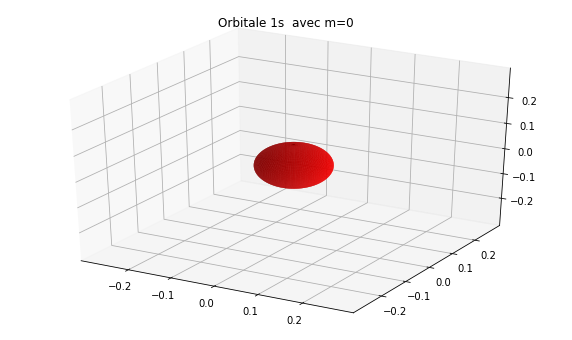

In [517]:
orb(1,0,0) #1s

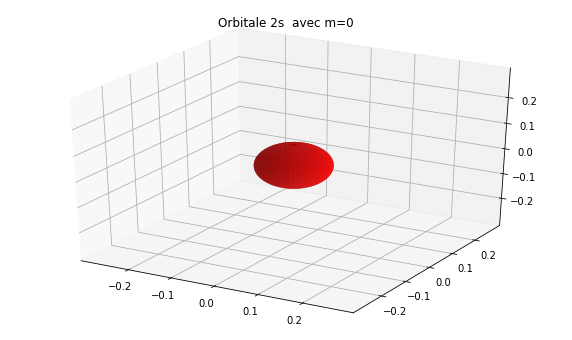

In [518]:
orb(2,0,0) #2s

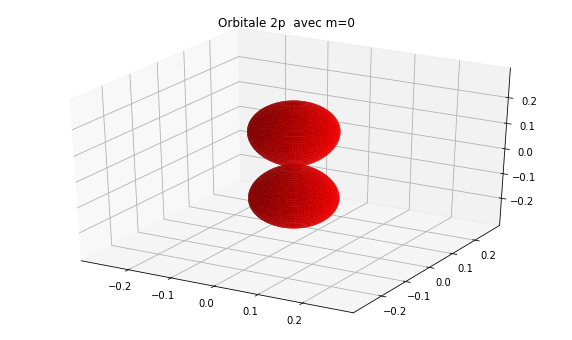

In [519]:
orb(2,1,0) # 2pz

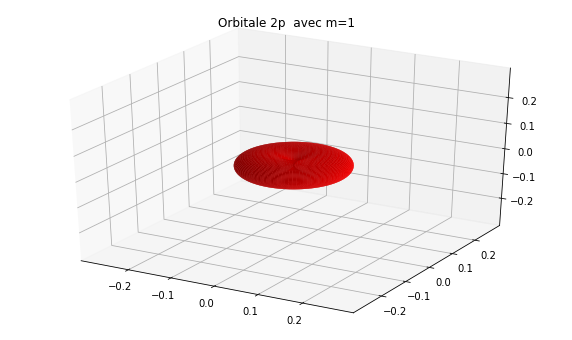

In [520]:
orb(2,1,+1) # 2px

On remarque que les orbitales 1s et 2s sont de la même forme, et que la valeur de m modifie la forme de l'orbitale.

# Deuxième partie: l'atome de sodium

Les fonctions qui suivent seront utilisées dans toute cette deuxième partie. 

In [528]:
n=10001
L=100
R=np.linspace(0,L,n) #vecteur des coordonnées r
R+=L/(n-1)


def potentiel_sodium(U,l,Rex):
    def pot_cin_orb(r):
        return l*(l+1)/(2*r**2)
    pot_cin_orb=np.vectorize(pot_cin_orb)
    return U+pot_cin_orb(Rex)

def rho(U,Rex): # e=1
    h=Rex[1]-Rex[0]
    Sch=Schrodinger(U)[1]
    Sch1=Schrodinger(potentiel_sodium(U,1,Rex))[1]
    S=-2*np.abs(Sch[:,0]/(h**0.5))**2 #l=0, n=0+l+1=1 donc 1s
    S-=2*np.abs(Sch[:,1]/(h**0.5))**2 #l=0, n=1+l+1=2 donc 2s
    S-=6*np.abs(Sch1[:,0]/(h**0.5))**2 #l=1, n=0+l+1=2 donc 2p
    for k in range(len(Rex)):
        S[k]=S[k]/((Rex[k])**2)
    return S

## 6

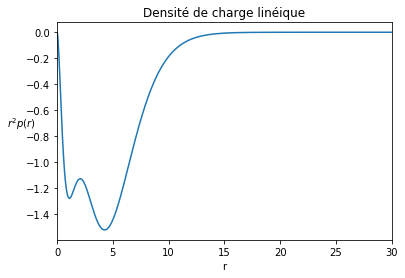

In [529]:
def r2rho(Rex): # e=1
    S=rho(Potentielhydrogène(Rex),Rex)
    for k in range(len(Rex)):
        S[k]=S[k]*((Rex[k])**2)
    return S

plt.plot(R, r2rho(R))
plt.title('Densité de charge linéique')
plt.xlabel('r')
plt.ylabel("$r^{2} p(r)$", rotation=360)
plt.xlim(0,30)
plt.show()

Cette fonction ne sera pas utilisée dans la suite.

## 7

Remarque: La charge élementaire e pourra être prise égale à 1 dans la suite. En effet, elle n'interviendra pas dans la résolution numérique de l'équation de Poisson.

On part du potentiel $U(r)=U_{infini}(r)$ (potentiel de l'électron de l'atome d'hydrogène).
On souhaite trouver la nouvelle forme de U(r).

En notant $u$ le potentiel $U_{e}(r)$ dû à Z - 1 électrons, l'équation de Poisson se réecrit matriciellement sous la forme:
$$\begin{bmatrix}
u^{'}\\u^{''}
\end{bmatrix} = \begin{bmatrix}
0 & 1 \\
0 & -2/r \\
\end{bmatrix} . \begin{bmatrix}
u \\ u^{'} 
\end{bmatrix} + \begin{bmatrix}
0 \\ -\frac{1}{e} \rho(r)
\end{bmatrix}$$
C'est à dire sous la forme: $$Y'=M.Y + C$$
Ces lettres seront utilisées dans la suite.

Connaissant la forme de $U_{e}(r)$ en l'infini, j'utilise celle-ci pour remonter pas à pas vers r=0 par une méthode d'Euler.

In [533]:
#e=1

def M(Rex,i):
    return np.array([[0,1],[0,-2/Rex[i]]])

def C(rho_eff,i):
    return np.array([0,-rho_eff[i]])

def U0(r):
    return -11/r
U0=np.vectorize(U0)

def U_iter1(Rex):
    h=Rex[1]-Rex[0]
    Long=Rex[n-1]
    U=Potentielhydrogène(Rex)
    Y=np.zeros((2,n))
    Y[0][n-1]=10/Long
    Y[1][n-1]=-10/(Long**2)
    
    Rho=rho(U,Rex) 

    for i in range(1,len(Rex)):
        Y[:,n-1-i]=Y[:,n-i]+h*((M(Rex,n-i).dot(Y[:,n-i])+C(Rho,n-i)))
    
    U=U0(Rex)+Y[0]
        
    return U

## 8

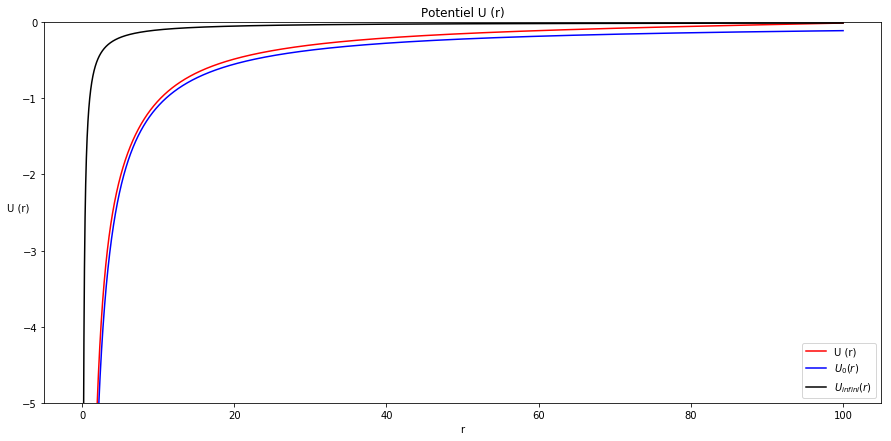

In [534]:
plt.figure(figsize=(15,7))
plt.plot(R,U_iter1(R), color='r', label='U (r)')
plt.plot(R,U0(R), color='b', label='$U_{0} (r)$')
plt.plot(R,Potentielhydrogène(R), color='k', label='$U_{infini} (r)$')

plt.title('Potentiel U (r)')
plt.xlabel('r')
plt.ylabel('U (r)', rotation=360)
plt.legend()
plt.ylim(-5,0)
plt.show()

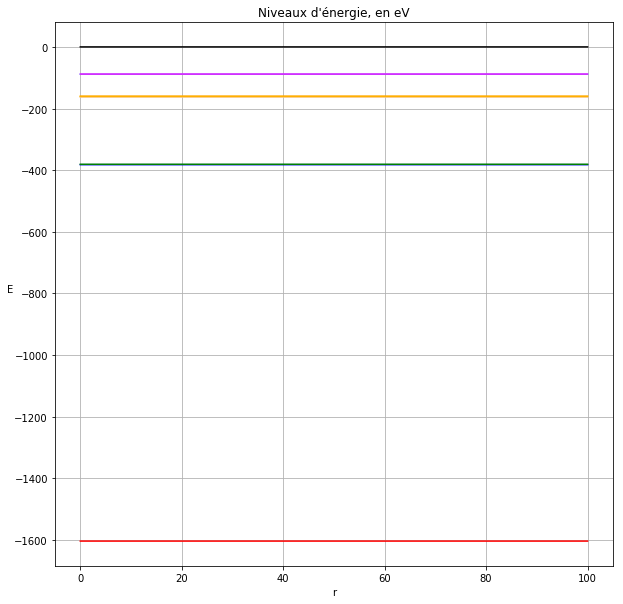

In [535]:
''''Application à l'atome de Sodium'''
Sch0Na=Schrodinger(U_iter1(R))[0]
Sch1Na=Schrodinger(potentiel_sodium(U_iter1(R),1,R))[0]
Sch2Na=Schrodinger(potentiel_sodium(U_iter1(R),2,R))[0]
En_Sod=[Sch0Na[0],Sch0Na[1],Sch1Na[0],Sch0Na[2],Sch1Na[1],Sch0Na[3],Sch2Na[0],Sch1Na[2]] # =[1s,2s,2p,3s,3p,4s,3d,4p]

diagr_En(En_Sod)

On remarque la levée de la dégenerescence des niveaux d'énergie, ainsi qu'un changement important des valeurs.

## 9

In [597]:
def U_iter(Rex, Nit_tot):
    h=Rex[1]-Rex[0]
    Long=Rex[n-1]
    U=Potentielhydrogène(Rex)
    Y=np.zeros((2,n))
    Y[0][n-1]=10/Long
    Y[1][n-1]=-10/(Long**2)
    
    for k in range(Nit_tot):
        Rho=rho(U,Rex)
        for i in range(1,len(Rex)):
            Y[:,n-1-i]=Y[:,n-i]+h*((M(Rex,n-i).dot(Y[:,n-i])+C(Rho,n-i)))
        U=0.5*(U0(Rex)+Y[0])+0.5*U #Pour aider la convergence
    
    En_Sod=[] 
    for l in range(4): #jusqu'aux sous-orbitales f
        Sch=Schrodinger(potentiel_sodium(U,l,Rex))[0]
        for i in range(8): #jusqu'à 8s, toutes les orbitales sont prises en compte
            En_Sod.append(Sch[i])
    
    return U, En_Sod 

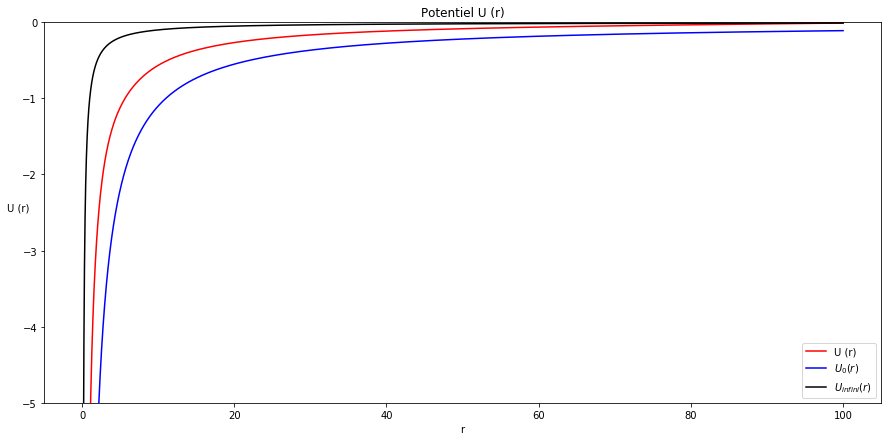

In [596]:
plt.figure(figsize=(15,7))
plt.plot(R,U_iter(R,1)[0], color='r', label='U (r)')
plt.plot(R,U0(R), color='b', label='$U_{0} (r)$')
plt.plot(R,Potentielhydrogène(R), color='k', label='$U_{infini} (r)$')

plt.title('Potentiel U (r)')
plt.xlabel('r')
plt.ylabel('U (r)', rotation=360)
plt.legend()
plt.ylim(-5,0)
plt.show()

Niveaux d'énergies en eV: [-471.9943468377001, -110.97471689399818, -47.435771524766814, -26.818969341450813, -17.362989106659292, -11.991582258412123, -8.658565097935245, -6.461318574812252, -110.00457075849786, -46.97039784690538, -26.5819159843731, -17.255516894189377, -11.935039370718105, -8.62454218490431, -6.439094675455746, -4.923273944491584, -46.202989801356686, -26.17200960375164, -17.089623006088438, -11.855781804768586, -8.579341470285966, -6.410513067777058, -4.90398906737409, -3.8145842819604083, -25.610372158605934, -16.920444299285357, -11.796018983066828, -8.551254436748444, -6.394856057137686, -4.894399008040161, -3.8084086755175157, -2.9953546035718808]


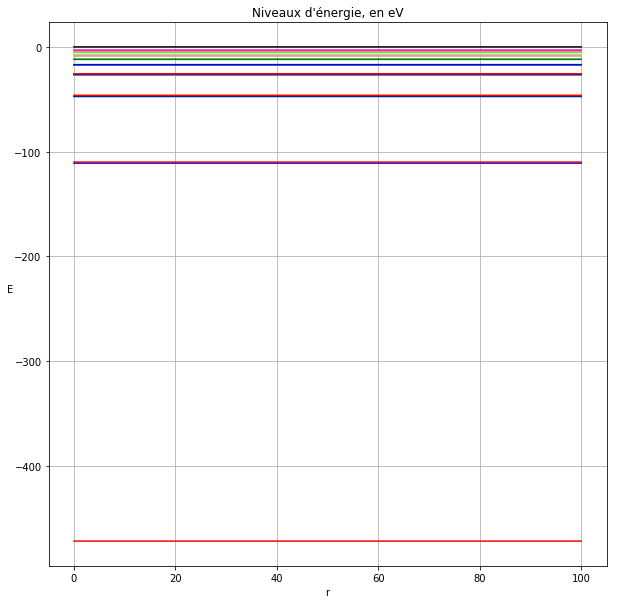

In [594]:
diagr_En(U_iter(R,1)[1])

## 10

In [ ]:
def U_iter(Rex, précision):
    epsilon=100
    k=0
    
    h=Rex[1]-Rex[0]
    Long=Rex[n-1]
    U=Potentielhydrogène(Rex)
    Y=np.zeros((2,n))
    Y[0][n-1]=10/Long
    Y[1][n-1]=-10/(Long**2)
    En_Sod=[] 
    
    while epsilon>précision: #en pourcentage
        Rho=rho(U,Rex)
        Eav=Schrodinger(U)[0][0]
        for i in range(1,len(Rex)):
            Y[:,n-1-i]=Y[:,n-i]+h*((M(Rex,n-i).dot(Y[:,n-i])+C(Rho,n-i)))
        U=0.5*(U0(Rex)+Y[0])+0.5*U
        
        Eap=Schrodinger(U)[0][0]
        epsilon=np.abs((Eap-Eav)/Eap)*100 # On considère que le niveau 1s, le plus sensible aux variations de U(r),
                                          # doit être stabilisé à epsilon %
    
    for l in range(4): #jusqu'aux sous-orbitales f
        Sch=Schrodinger(potentiel_sodium(U,l,Rex))[0]
        for i in range(8): #jusqu'à 8s, toutes les orbitales sont prises en compte
            En_Sod.append(Sch[i])
    return U, En_Sod 

## 11